# Le duel de style

Construit à partir de [`STYLE_DUEL.md`](../STYLE_DUEL.md) — la spécification de design complète pour ce visuel.

Ce notebook charge les artefacts déjà calculés par [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp) (Phases 3, 4 et 6 : `eda_summary.csv`, `affect_summary.csv`, `phase6_*`), sans ré-exécuter aucun script `build_*.py` de ce dépôt, et produit les 3 images de `portfolio/01_style_duel/assets/` :

1. `radar_main.png` — le radar principal (6 traits stylométriques × 4 Premiers ministres)
2. `feature_importance.png` — pourquoi ces traits comptent (importance de permutation, Phase 6)
3. `confusion_matrix.png` — le classifieur retrouve-t-il le bon Premier ministre ?

Prérequis : `hansard-pm-nlp` cloné en dossier frère (`../hansard-pm-nlp`) ou `HANSARD_PM_NLP_DIR` pointant dessus — voir le README racine de ce dépôt.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import style_duel as viz

ASSETS_DIR = Path("../portfolio/01_style_duel/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. Bannière README

In [2]:
fig = viz.plot_banner("Le duel de style", "hansard-pm-portfolio · projet 01")
viz.save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Profil stylométrique — le radar

5 des 6 axes viennent directement des exports Phase 3/4 d'`hansard-pm-nlp` (`eda_summary.csv`, `affect_summary.csv`) — les mêmes que l'onglet "Stylometric profile by PM" du dashboard live. Le 6ᵉ (`fw_not_rate`, fréquence du mot « not ») est recalculé ici avec le même tokenizer pur-regex qu'`hansard_pm_nlp.lexical.tokenize_words` (aucune dépendance lourde ajoutée) car Phase 6 ne l'a exporté que pour 3 des 4 Premiers ministres (Truss exclue du classifieur). Voir `ARCHITECTURE.md` pour le détail de ce choix, y compris la substitution de `pos_INTJ` (spec initiale) par `mean_words_per_sentence`.

In [3]:
profile = da.load_style_profile()
profile[["pm_name", "n_contributions"] + [c for c, _ in da.RADAR_AXES]]

,pm_name,n_contributions,mtld,mean_flesch_kincaid_grade,mean_hedge_rate,mean_net_certainty,fw_not_rate,mean_words_per_sentence
0,Boris Johnson,5459,76.797033,9.423627,0.011333,0.005059,0.005349,19.693269
1,Keir Starmer,2896,77.742498,8.956253,0.007267,0.008541,0.006298,18.078021
2,Liz Truss,123,76.378099,9.424829,0.004625,0.015994,0.006673,18.172306
3,Rishi Sunak,2195,87.367750,10.738651,0.006038,0.007699,0.004794,20.937373


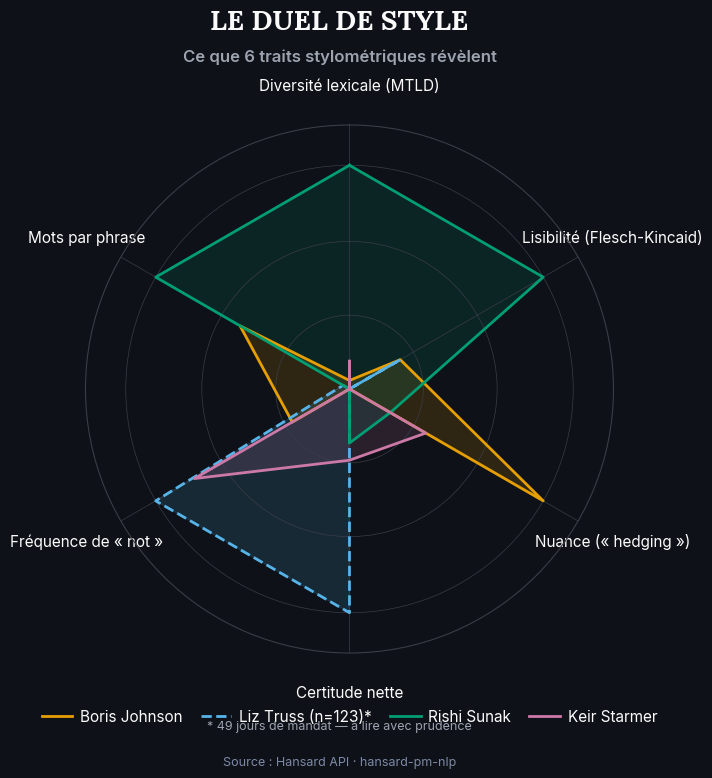

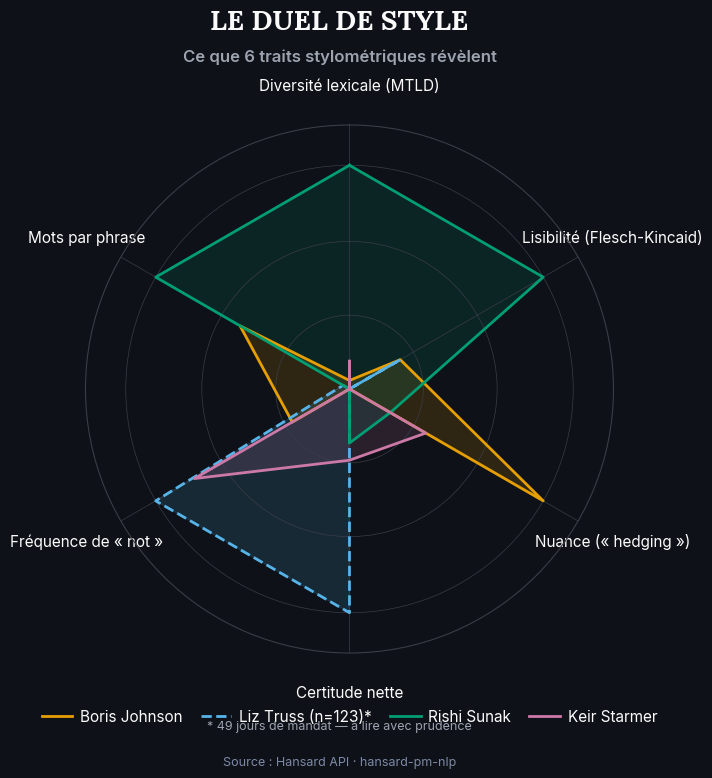

In [4]:
fig = viz.plot_style_radar(profile)
viz.save(fig, ASSETS_DIR / "radar_main.png")
fig

## 2. Pourquoi ces traits comptent — importances de permutation

Phase 6 exporte le top 15 (par modèle) des importances de permutation calculées sur le jeu de test (`phase6_feature_importance_hgb.csv`, `phase6_feature_importance_logreg.csv`). On retient ici le top 6 du modèle le plus précis (HistGradientBoosting, 93,2 % d'exactitude) — pas nécessairement les 6 traits exacts du radar ci-dessus : `flesch_kincaid` et `fw_not` n'apparaissent dans le top 15 d'aucun des deux modèles, donc aucune valeur de permutation-importance n'existe pour eux. 3 des 6 traits du radar (`mtld`, `hedge_rate`, `mean_words_per_sentence`) recoupent bien ce top 6.

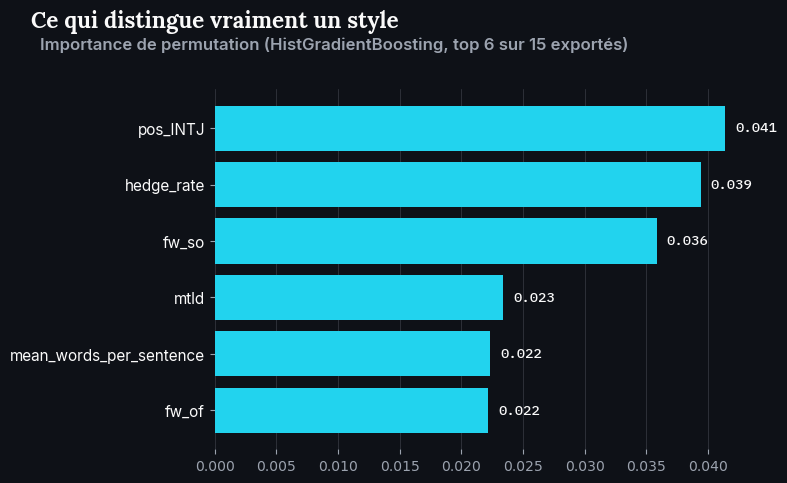

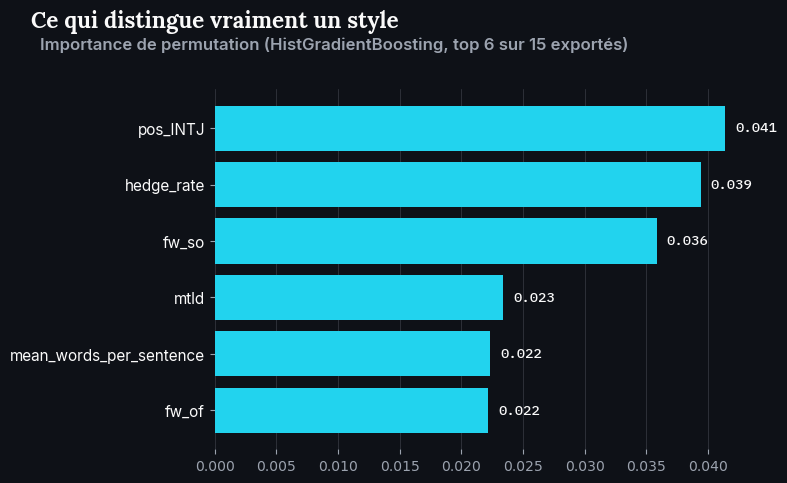

In [5]:
importance = da.load_feature_importance("hgb").head(6).sort_values("importance")
fig = viz.plot_feature_importance_bar(
    importance,
    "Ce qui distingue vraiment un style",
    "Importance de permutation (HistGradientBoosting, top 6 sur 15 exportés)",
)
viz.save(fig, ASSETS_DIR / "feature_importance.png")
fig

## 3. Le classifieur retrouve-t-il le bon Premier ministre ?

3 classes (Boris Johnson, Rishi Sunak, Keir Starmer) — Liz Truss exclue par Phase 6 elle-même (5 documents, mandat de 49 jours, trop peu pour un split train/test fiable ; voir `hansard-pm-nlp/src/hansard_pm_nlp/split.py`). Matrice normalisée par ligne (% des séances de test de chaque PM réel).

In [6]:
predictions = da.load_test_predictions()
metrics = da.load_classifier_metrics()
hgb_accuracy = metrics.set_index("model").loc["hgb", "accuracy"]
matrix = da.build_confusion_matrix(predictions, "pred_hgb")
matrix.round(1)

pred_hgb,Boris Johnson,Rishi Sunak,Keir Starmer
pm_name,,,
Boris Johnson,93.1,6.9,0.0
Rishi Sunak,0.0,92.3,7.7
Keir Starmer,5.9,0.0,94.1


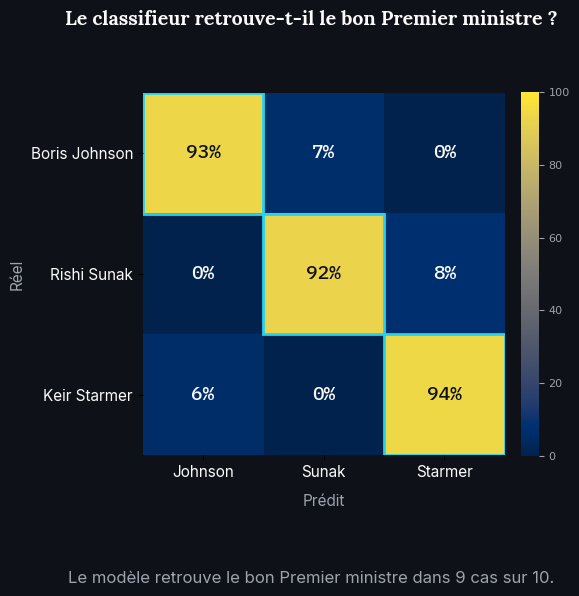

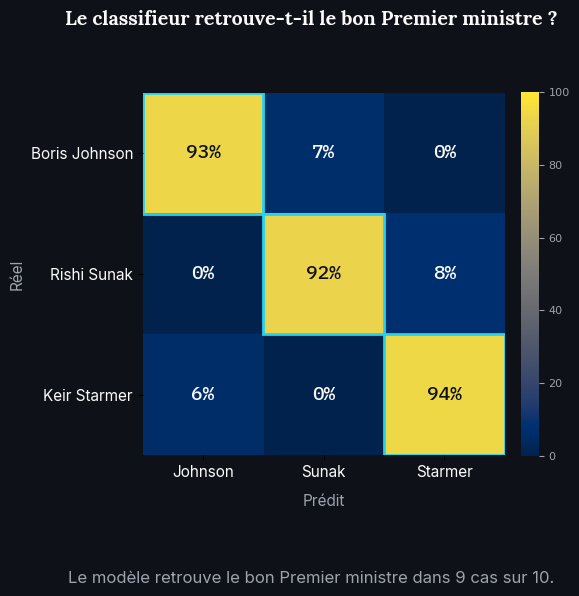

In [7]:
fig = viz.plot_confusion_matrix(matrix, hgb_accuracy)
viz.save(fig, ASSETS_DIR / "confusion_matrix.png")
fig

## Liens

- Spécification complète : [`STYLE_DUEL.md`](../STYLE_DUEL.md)
- Rapport source du classifieur : [`phase6_classifier_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase6_classifier_report.md) (dans `hansard-pm-nlp`)
- Dashboard interactif : voir le README racine de `hansard-pm-nlp`
- README de ce projet : [`portfolio/01_style_duel/README.md`](../portfolio/01_style_duel/README.md)